<!--Información del curso-->
<img align="left" style="padding-right:10px;" src="figuras/banner_cd.png">

<center><h1 style="font-size:2em;color:#2467C0"> Información de las sabanas del INE recolecta por el movimiento #YOSOY132 en la elección presidencial 2012  </h1></center>



<br>
<table>
<col width="650">
<col width="550">
<tr>
<td><img src="figuras/contamos.png" align="middle" style="width:700px"/></td>
<td>
    

Durante las elecciones presidenciales del año 2012, el colectivo #YOSOY132 pidió a la ciudadanía enviar la foto de su sabana con los resultados de su casilla.

    
</td>
</tr>
</table>

<div class="alert alert-success">
    
**Ejericicio**
* Hacer equipos de 2 o 3 integrantes.
* Hacer un análisis de los datos del directorio SABANAS_ELECCION_2012 
* Presentar los resultados obtenidos (enviar la presentación al profesor antes de comenzar la clase, junto con el código)
* Responder a la pregunta ¿Son confiables los datos? (Justificar su respuesta)
* Entregables por estudiantes: Presentación y archivo .ipynb
</div>

# **Contexto**
Fueron las elecciones de 2012, y existían en ese momento 12 coaliciones
- **PAN** (Partido Accion Nacional)
- **PRI** (Partido Revolucionario Institucional)
- **PRD** (Partido de la Revolución Democrática)
- **Partido Verde**
- **Movimiento Ciudadano**
- **PT** (Partido del Trabajo)
- **Nueva Alianza**
- **Compromiso por México (_PRI y Partido Verde_)**
- **Movimiento Progresista (_PRD, PT y Movimiento Ciudadano_)**
    * **PRD y PT**
    * **PRD y Movimiento Ciudadano**
    * **PT y Movimiento Ciudadano**

Los candidatos a la presidencia durante las elecciones del 2012 fueron:
- **Josefina Vasquez Mota**: PAN
- **Enrique Peña Nieto**: Compromiso por México
- **Andrés Manuel López Obrador**: Movimiento Progresista
- **Gabriel Quadri de la Torre**: Nueva Alianza

Los resultados de la elección, según la [TEPJF](https://te.gob.mx/consulta/), EPN ganó con 19,226,784 votos a favor.

In [ ]:
import json

## **Análisis de los datos**
### **Lector de archivos JSON**
A partir de los datos obtenidos del colectivo #132, se implemento un lector de archivos json  
que lee trozos de muestras en cada archivo .json del conjunto de datos.  
A continuación se muestra la estructura de cada archivo por medio del visualizador de campos del archivo JSON

In [269]:
# Visualizador de campos de datos JSON
def visualizar_json(ruta:str):
    print("JSON fields")
    with open(ruta) as archivo:
        datos = json.load(archivo)
        visualizar_campos_json(datos, 0)

def visualizar_campos_json(datos:dict, indent:int):   
    indent+=1
    for campo in datos:
        print("\t"*indent+campo)
        if isinstance(datos[campo], list):
            visualizar_campos_json(datos[campo][0], indent)
        if isinstance(datos[campo], dict):
            visualizar_campos_json(datos[campo], indent)

#USO
visualizar_json('SABANAS_INE_ELECCION_2012/file_id-0.json')


JSON fields
	sabanas
		id
		proyecto
		fuente
		imagen
		imagen_original
		entidad
		municipio
		distrito
		seccion
		tipoCasilla
		sha
		idcasilla
		revision
		resultados
			pan
			pri
			prd
			verde
			pt
			mov
			nuevaAlianza
			pri_verde
			prd_pt_mov
			prd_pt
			prd_mov
			pt_mov
			noRegistrados
			nulos


### **Implementación del lector y el procesador de datos**
En la parte superior del código, se encuentra la implementación del lector, mientras que en  
la parte inferior se encuentra la lógica de la aplicación.

#### El funcionamiento resumido de la aplicación:
- **procesar(sabana:_dict_)**: Es el pipeline de la aplicación, donde implementa varias funciones  
que nos va interesar a continuación.  
**procesar_resultados()**: Es el método que se encarga de leer los resultados de la casilla.
- El tipo de información que recolecta el procesador es:
    * Resultados en votos
    * Valores ingresados por cada campo en cada sabana
    * Casillas por entidad
    * Votos válidos por entidad
    * Votos válidos por coalición por cada entidad

In [295]:
# Recolector de datos
def leer_datos(directorio:str, ruta:str):
    muestra_total = 0
    with open(directorio+ruta) as archivo:
        for linea in archivo:
            archivo_trozo = linea.rstrip()
            muestra_total+=leer_por_trozo(directorio, archivo_trozo)
    print(f'Se leyeron {muestra_total} datos')

def leer_por_trozo(directorio:str, archivo:str):
    muestra_trozo = 0
    with open(directorio+archivo) as trozo:
        datos = json.load(trozo)
        muestra_trozo+=procesar(datos['sabanas'])
    return muestra_trozo

# =========================================================================
# Aplicación: Lector de sabanas
# DATOS RELEVANTES
# Valores posibles: campo --> conjunto de valores
valores = dict()
# Resultados: partido --> numero de votos presidenciales
resultados = dict()
casillas_por_entidad = dict()
votos_por_entidad = dict()
votos_generales_por_entidad = dict()

def procesar(sabana:dict):
    muestra = 0
    for casilla in sabana:
        muestra = contar(muestra)
        # Metodos para recolectar
        entidad = casilla['entidad']
        # 1. valores
        obtener_valores_en(valores, casilla, 'tipoCasilla')
        obtener_valores_en(valores, casilla, 'entidad')
        # 2. Contar casillas por
        contar_casilla_por(casillas_por_entidad, entidad)
        # 3. Conteo de votos
        total = procesar_resultados(casilla)
        contar_votos_por(votos_generales_por_entidad, entidad, total)
    return muestra

def procesar_resultados(casilla:dict):
    entidad = casilla['entidad']
    resultados_c = casilla['resultados']
    total_votos = 0
    for grupo in resultados_c:
        # Descartar votos no registrados
        match grupo:
            case 'noRegistrados' | 'nulos': continue
        num_votos_c = int(resultados_c[grupo])
        contar_votos_por(resultados, grupo, num_votos_c)
        contar_votos_dado_por(votos_por_entidad, [entidad, grupo], num_votos_c)
        total_votos += num_votos_c
    return total_votos

def contar(res:int):
    return res + 1

def contar_casilla_por(res:dict, patron:str):
    res[patron] = res.get(patron, 0) + 1

def contar_votos_por(res:dict, patron:str, votos:int):
    res[patron] = res.get(patron, 0) + votos

def contar_votos_dado_por(res:dict, patrones:list[str], votos:int, i:int=0):
    patron = patrones[i]
    if len(patrones) - 1 == i: 
        res[patron] = res.get(patron, 0) + votos
    else: 
        res[patron]= res.get(patron, dict())
        contar_votos_dado_por(res[patron], patrones, votos, i+1)

def obtener_valores_en(res:dict, casilla:dict, campo:str):
    res[campo] = res.get(campo, set())
    res[campo].add(casilla[campo])
# ========================================================================

#USO
leer_datos('SABANAS_INE_ELECCION_2012/', 'nombre_archivos.txt')
resultados

Se leyeron 23000 datos


{'pan': 2247447,
 'pri': 2030613,
 'prd': 2253197,
 'verde': 93164,
 'pt': 255192,
 'mov': 208921,
 'nuevaAlianza': 203491,
 'pri_verde': 621972,
 'prd_pt_mov': 787276,
 'prd_pt': 128348,
 'prd_mov': 42425,
 'pt_mov': 22251}

### **Post - Análisis**
Se computan los resultados, por candidato, se realiza un diccionario para relacionar candidatos  
con cada coalición.
De este modo se obtienen dos resultados:
* Resultados generales.
* Resultados por entidad.

In [276]:
# ==================================================
# Post - Analisis
coaliciones_candidatos = {
    "Enrique Peña Nieto": {"pri", "verde"},
    "Josefina Vasquez Mota": {"pan"},
    "Andrés Manuel López Obrador": {"prd", "pt", "mov"},
    "Gabriel Quadri de la Torre": {"nuevaAlianza"}
}

resultados_generales_candidatos = dict()
resultados_entidades_candidatos = dict()

def computar_resultados_por_candidatos(res:dict, resultados:dict):
    for partido, votos in resultados.items():
        partidos = set(partido.split('_'))
        for candidato, grupo in coaliciones_candidatos.items():
            if partidos <= grupo:
                res[candidato] = res.get(candidato, 0) + votos
    return res

def computar_resultados_por_candidatos_por_entidad():
    for entidad, resultados_e in votos_por_entidad.items():
        resultados_entidades_candidatos[entidad] = resultados_entidades_candidatos.get(entidad, dict())
        computar_resultados_por_candidatos(resultados_entidades_candidatos[entidad], resultados_e)
# =================================================

#USO
computar_resultados_por_candidatos(resultados_generales_candidatos, resultados)
computar_resultados_por_candidatos_por_entidad()

print(resultados_generales_candidatos)
print(resultados_entidades_candidatos)

{'Josefina Vasquez Mota': 2247447, 'Enrique Peña Nieto': 2745749, 'Andrés Manuel López Obrador': 3697610, 'Gabriel Quadri de la Torre': 203491}
{'9': {'Josefina Vasquez Mota': 502860, 'Enrique Peña Nieto': 648092, 'Andrés Manuel López Obrador': 1299021, 'Gabriel Quadri de la Torre': 44178}, '5': {'Josefina Vasquez Mota': 51554, 'Enrique Peña Nieto': 39996, 'Andrés Manuel López Obrador': 32063, 'Gabriel Quadri de la Torre': 3459}, '2': {'Josefina Vasquez Mota': 127975, 'Enrique Peña Nieto': 144677, 'Andrés Manuel López Obrador': 162113, 'Gabriel Quadri de la Torre': 12460}, '21': {'Josefina Vasquez Mota': 204347, 'Enrique Peña Nieto': 176430, 'Andrés Manuel López Obrador': 285548, 'Gabriel Quadri de la Torre': 16764}, '25': {'Josefina Vasquez Mota': 20008, 'Enrique Peña Nieto': 31787, 'Andrés Manuel López Obrador': 25877, 'Gabriel Quadri de la Torre': 1523}, '7': {'Josefina Vasquez Mota': 18082, 'Enrique Peña Nieto': 42484, 'Andrés Manuel López Obrador': 53097, 'Gabriel Quadri de la Tor

# **Presentación de los datos**

Podemos usar un mapa adicionalmente para asociar valores de las entidades por número  
(dado que en cada archivo JSON, las entidades se guardan por su número en orden alfabético).

In [277]:
# Un mapa para visualizar mejor las entidades
entidades_mexico = {
    1:  "Aguascalientes",
    2:  "Baja California",
    3:  "Baja California Sur",
    4:  "Campeche",
    5:  "Coahuila",
    6:  "Colima",
    7:  "Chiapas",
    8:  "Chihuahua",
    9:  "Ciudad de México",
    10: "Durango",
    11: "Guanajuato",
    12: "Guerrero",
    13: "Hidalgo",
    14: "Jalisco",
    15: "Estado de México",
    16: "Michoacán",
    17: "Morelos",
    18: "Nayarit",
    19: "Nuevo León",
    20: "Oaxaca",
    21: "Puebla",
    22: "Querétaro",
    23: "Quintana Roo",
    24: "San Luis Potosí",
    25: "Sinaloa",
    26: "Sonora",
    27: "Tabasco",
    28: "Tamaulipas",
    29: "Tlaxcala",
    30: "Veracruz",
    31: "Yucatán",
    32: "Zacatecas"
}
# Aqui asignamos el nombre real conforme al numero de la entidad
for entidad, votos in sorted(resultados_entidades_candidatos.items(), key=lambda item: int(item[0])):
    nombre = entidades_mexico[int(entidad)]
    print(f"\n{nombre}:")
    for candidato, total in votos.items():
        print(f"  {candidato}: {total}")


Aguascalientes:
  Josefina Vasquez Mota: 22048
  Enrique Peña Nieto: 23572
  Andrés Manuel López Obrador: 17905
  Gabriel Quadri de la Torre: 3965

Baja California:
  Josefina Vasquez Mota: 127975
  Enrique Peña Nieto: 144677
  Andrés Manuel López Obrador: 162113
  Gabriel Quadri de la Torre: 12460

Baja California Sur:
  Josefina Vasquez Mota: 12269
  Enrique Peña Nieto: 15461
  Andrés Manuel López Obrador: 11314
  Gabriel Quadri de la Torre: 811

Campeche:
  Josefina Vasquez Mota: 10400
  Enrique Peña Nieto: 13896
  Andrés Manuel López Obrador: 15708
  Gabriel Quadri de la Torre: 1110

Coahuila:
  Josefina Vasquez Mota: 51554
  Enrique Peña Nieto: 39996
  Andrés Manuel López Obrador: 32063
  Gabriel Quadri de la Torre: 3459

Colima:
  Josefina Vasquez Mota: 16177
  Enrique Peña Nieto: 15821
  Andrés Manuel López Obrador: 12161
  Gabriel Quadri de la Torre: 796

Chiapas:
  Josefina Vasquez Mota: 18082
  Enrique Peña Nieto: 42484
  Andrés Manuel López Obrador: 53097
  Gabriel Quadri d

## **Visualización**
Usaremos `matplotlib` para representar los resultados obtenidos, aquí importamos  
y definimos métodos para presentar los datos.

In [278]:
# Visualizar en matplotlib
import matplotlib.pyplot as plt
import textwrap as tw
import colorsys as color

def acomodar_etiquetas(etiquetas, ancho):
    return ['\n'.join(tw.wrap(etiqueta, ancho)) for etiqueta in etiquetas]

<div class='alert alert-warning'>  

## Resultados obtenidos de las elecciones presidenciales (#YoSoy132)
Los resultados que se obtuvieron del colectivo, sugieren que Andrés Manuel López Obrador   
habría resultado el presidente electo, pero no se tiene certeza si ésta muestra es representativa  
a los datos mostrados del TEPJF

</div> 

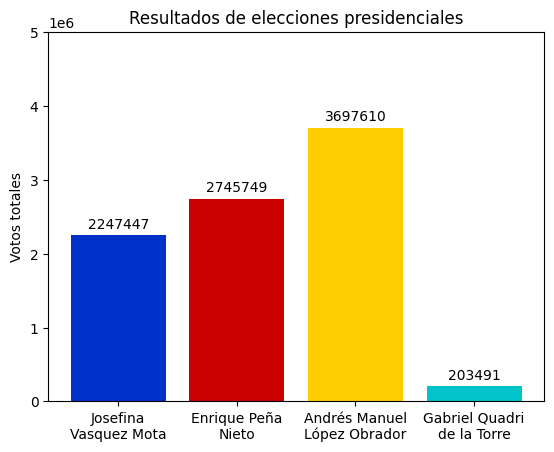

In [304]:
# Visualizar los votos generales por candidato
res_g_candidato = resultados_generales_candidatos.copy()

# Candidatos
candidatos = acomodar_etiquetas(res_g_candidato.keys(), 15)
votos = res_g_candidato.values()

c_colores = ['#0032CA', '#CA0000', '#FFCE00', '#00C4CA']

# Propiedades de la grafica
fig, ax = plt.subplots()

# Crear una gráfica
valor = ax.bar(candidatos, votos, color=c_colores)
ax.bar_label(valor, padding=3, fmt='%i')

ax.set_ylabel('Votos totales')
ax.set_ylim(0,5000000)

ax.set_title('Resultados de elecciones presidenciales')

plt.show()

<div class='alert alert-warning'>  

## Votos obtenidos por entidad federativa (#YoSoy132)
Una manera para encontrar la representatitividad de los resultados recabados, se realizó  
una clasificación por entidad federativa, para encontrar la proporción y por tanto la  
representatividad de la muestra. El siguiente paso sería recabar los datos de acuerdo con
lo publicado en la TEPJF

</div> 

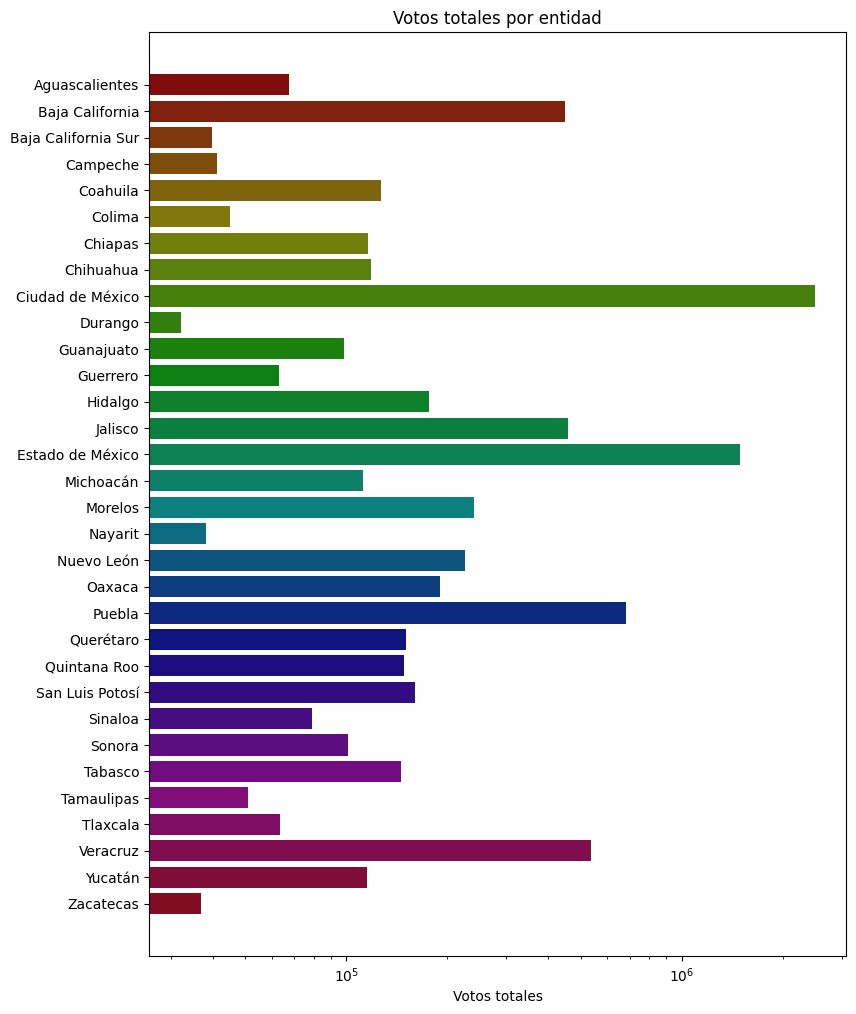

In [ ]:
# Visualizar los votos por entidad
res_g_entidad = dict(sorted(votos_generales_por_entidad.items(), key= lambda item : int(item[0])))
# Darle un significado al numero de entidades
estados_et = tuple(entidades_mexico[int(x)] for x in res_g_entidad.keys())

# Propiedades de la grafica
fig, ax = plt.subplots(figsize=(9,12))
y_pos = range(len(estados_et))
colores = [color.hsv_to_rgb(i/len(estados_et), 0.9, 0.5) for i in y_pos]

# Crear una gráfica horizontal
ax.barh(y_pos, res_g_entidad.values(), align='center', color=colores)
ax.set_yticks(y_pos, labels=estados_et)
ax.invert_yaxis()

ax.set_xscale('log')
ax.set_xlabel('Votos totales')

ax.set_title('Votos totales por entidad')

plt.show()

C:\Users\pablo\AppData\Local\Temp\ipykernel_23772\241418222.py:20: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 5000000)


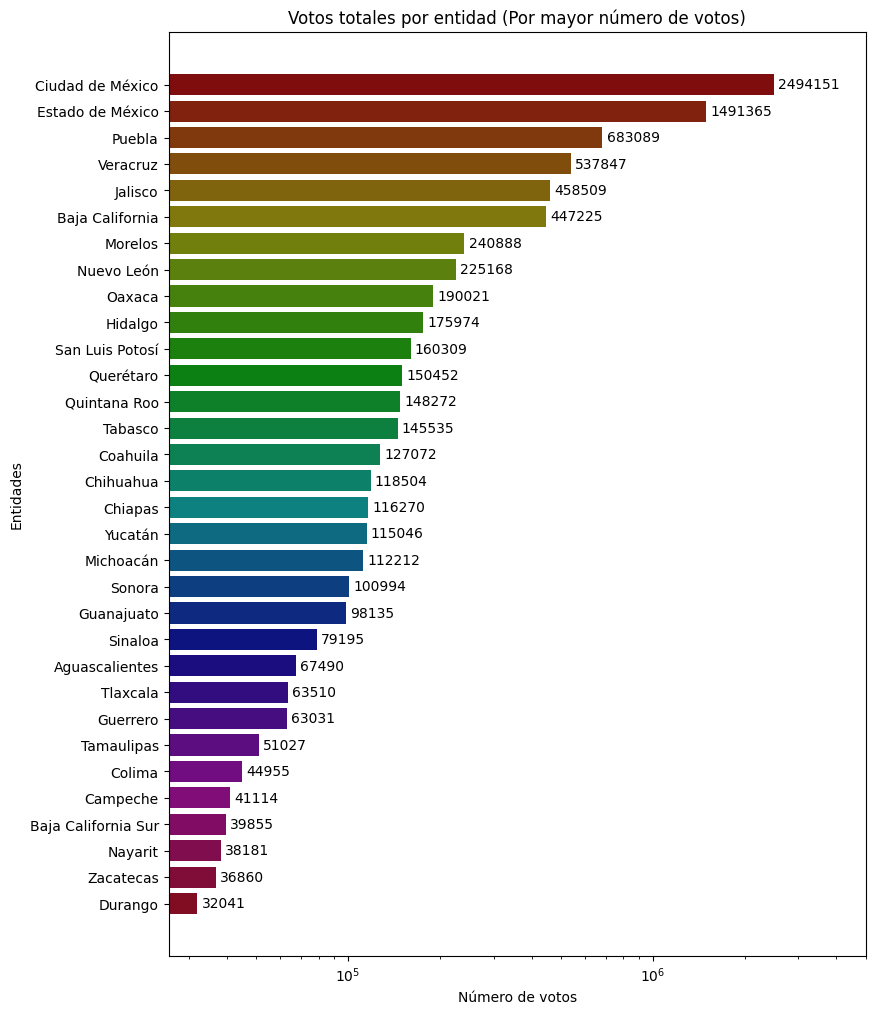

In [302]:
# Visualizar los votos por entidad de manera ordenada
res_g_entidad = dict(sorted(votos_generales_por_entidad.items(), key= lambda item : int(item[1]), reverse=True))
# Darle un significado al numero de entidades
estados_et = tuple(entidades_mexico[int(x)] for x in res_g_entidad.keys())

# Propiedades de la grafica
fig, ax = plt.subplots(figsize=(9,12))
y_pos = range(len(estados_et))
colores = [color.hsv_to_rgb(i/len(estados_et), 0.9, 0.5) for i in y_pos]

# Crear una gráfica horizontal
valor = ax.barh(y_pos, res_g_entidad.values(), align='center', color=colores)
ax.bar_label(valor, padding=3, fmt='%i')
ax.set_yticks(y_pos, labels=estados_et)
ax.set_ylabel('Entidades')
ax.invert_yaxis()

ax.set_xscale('log')
ax.set_xlabel('Número de votos')
ax.set_xlim(0, 5000000)

ax.set_title('Votos totales por entidad (Por mayor número de votos)')

plt.show()

<div class='alert alert-warning'>  

## Resultados obtenidos por entidad federativa (#YoSoy132)
Adicionalmente se muestran los resultados que se tuvieron por entidad federativa.  
Pero aun así, es necesario recabar los datos de acuerdo con lo publicado en la TEPJF

</div> 

C:\Users\pablo\AppData\Local\Temp\ipykernel_23772\3224325306.py:34: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0,5000000)


Text(0.5, 1.0, 'Resultados de elecciones presidenciales (por entidad)')

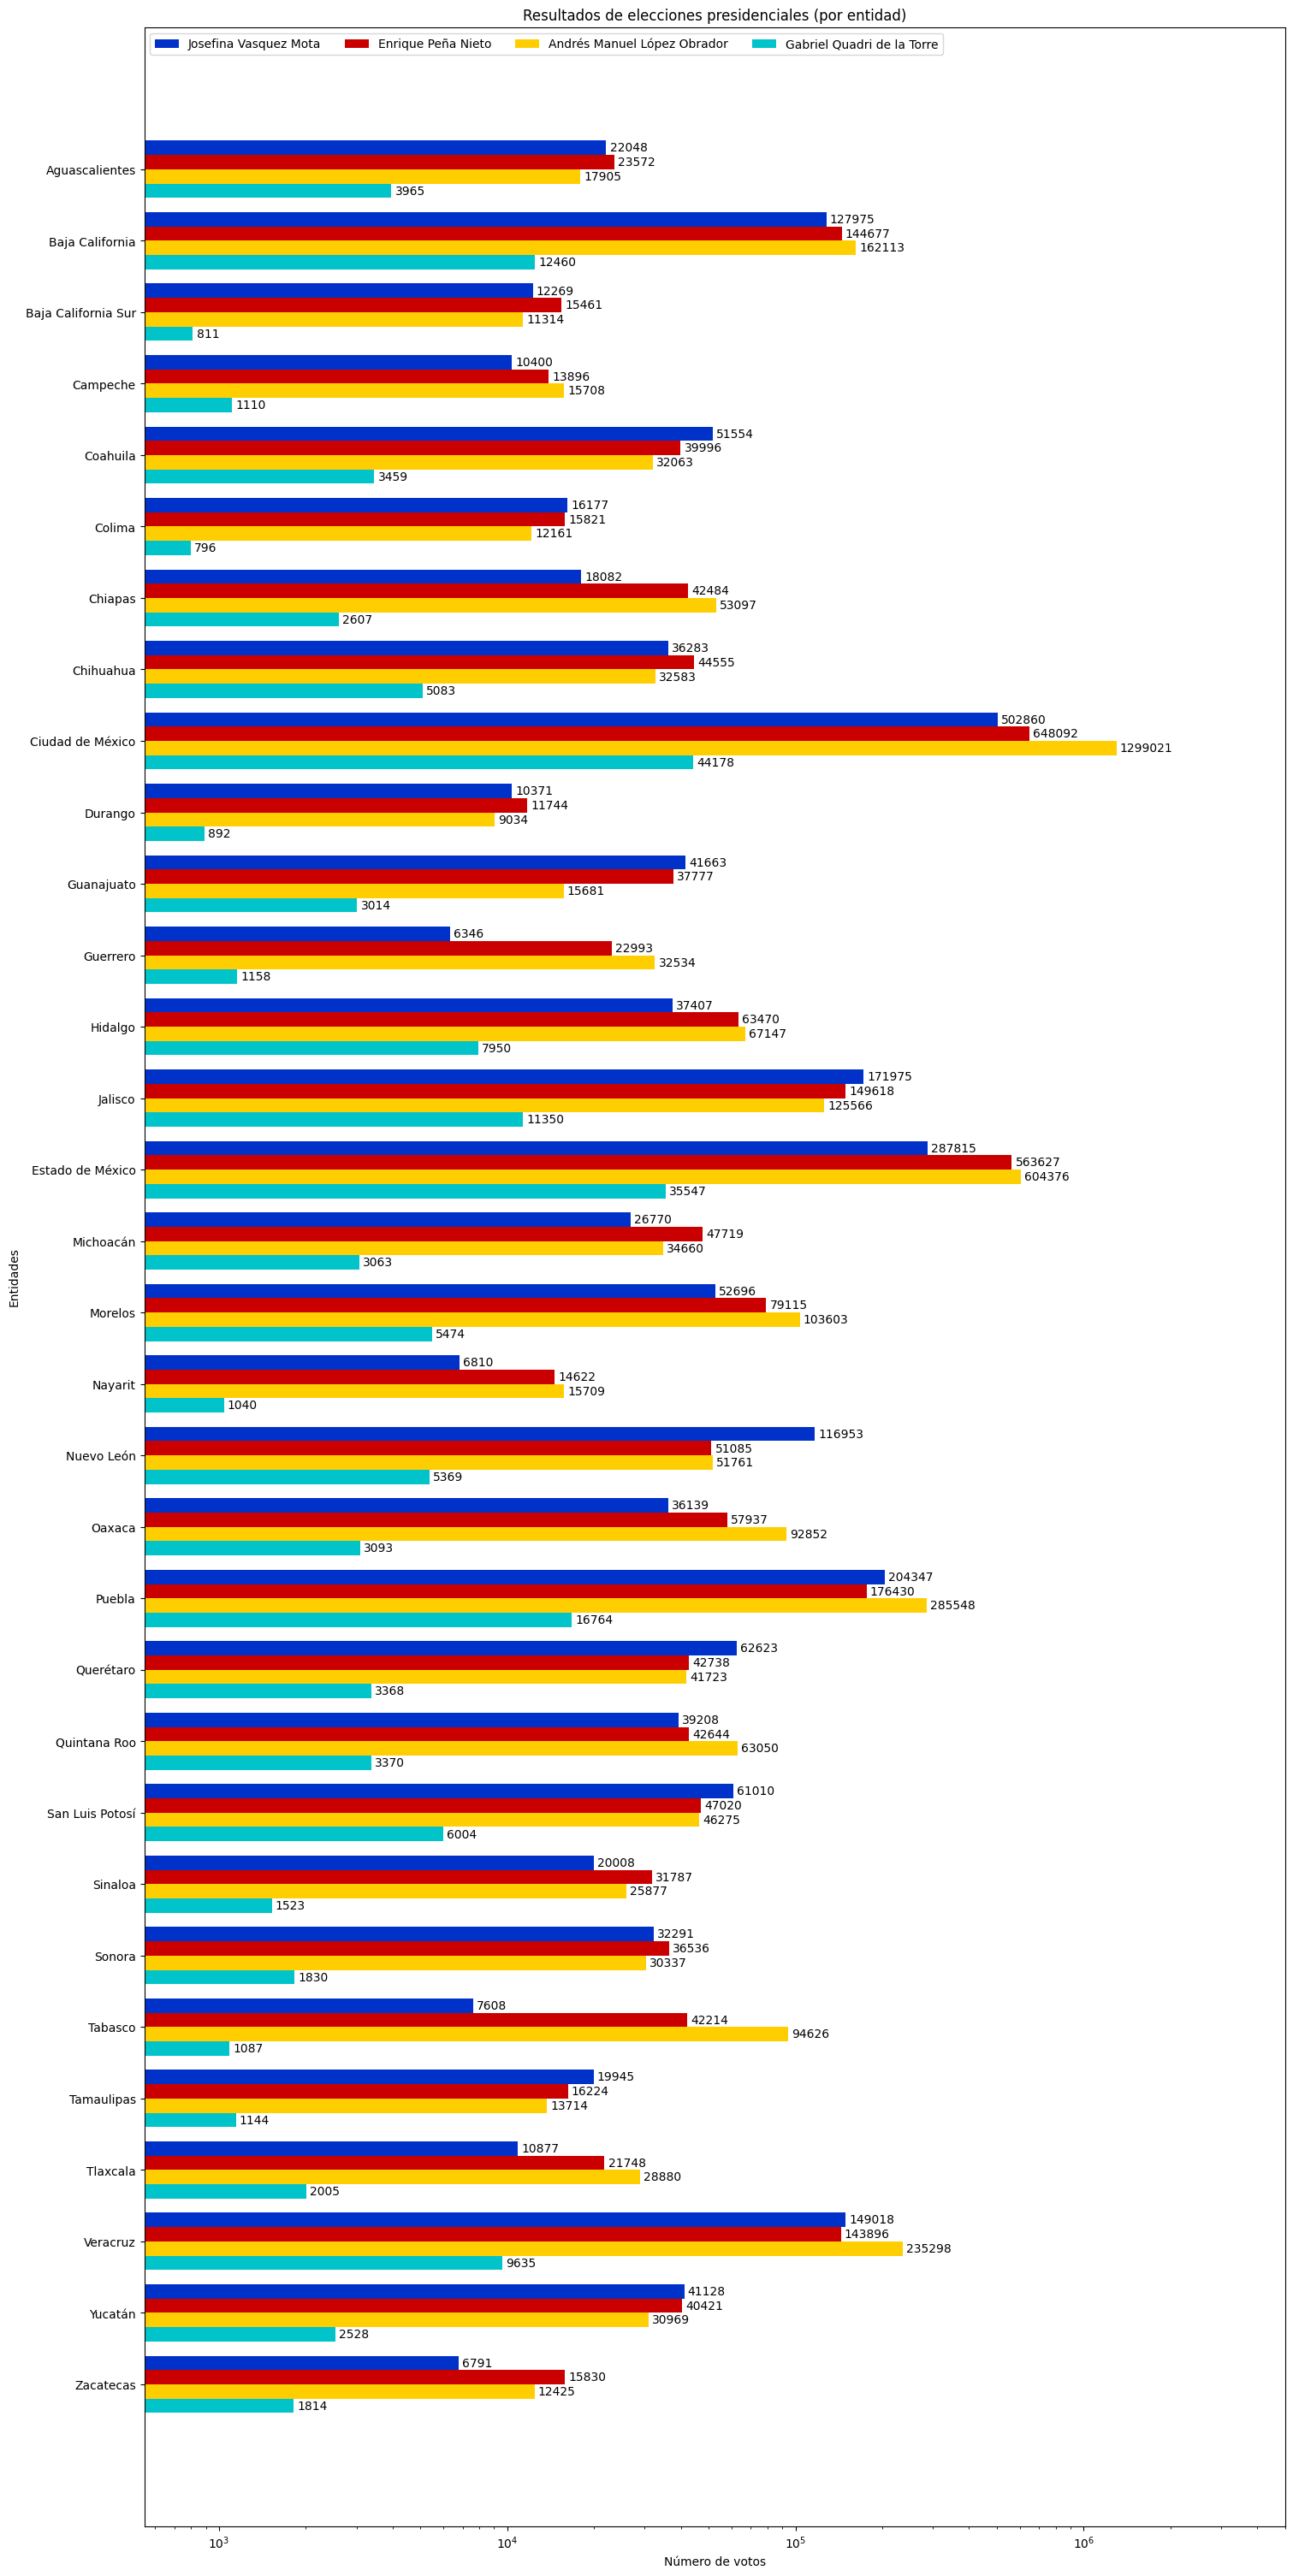

In [300]:
# Visualizar los votos por candidato en cada entidad
res_e_candidato = dict(sorted(resultados_entidades_candidatos.items(), key= lambda item : int(item[0])))

# Preparar los resultados
modelo_candidatos = dict()
for entidad, resultados in res_e_candidato.items():
    for candidato, votos in resultados.items():
        modelo_candidatos[candidato] = modelo_candidatos.get(candidato, list())
        modelo_candidatos[candidato].append(votos)

# Darle un significado al número de entidades
estados_et = tuple(entidades_mexico[int(x)] for x in res_e_candidato.keys())

# Propiedades de la grafica
fig, ax = plt.subplots(figsize=(15,30),layout='constrained')
y_pos = list(range(len(estados_et)))
ancho_barra = 0.2

for i, (candidato, votos_entidad) in enumerate(modelo_candidatos.items()):
    desplazamiento = ancho_barra * i
    y_i = [y + desplazamiento for y in y_pos]
    barra = ax.barh(y_i, votos_entidad, ancho_barra, label=candidato, color=c_colores[i])
    ax.bar_label(barra, padding=3, fmt='%i')

# Crear una gráfica
ax.set_ylabel('Entidades')
centro = ancho_barra * (len(modelo_candidatos) - 1) / 2
ax.set_yticks([y + centro for y in y_pos])
ax.set_yticklabels(estados_et)
ax.invert_yaxis()

ax.set_xlabel('Número de votos')
ax.set_xscale('log')
ax.set_xlim(0,5000000)

ax.legend(loc='upper left', ncols=4)
ax.set_title('Resultados de elecciones presidenciales (por entidad)')